In [ ]:
!pip install yfinance

## First Question

In [2]:
import pandas as pd
import requests

# URL of the Wikipedia page
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Set headers to mimic a browser request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Fetch the HTML content with headers
response = requests.get(url, headers=headers)

In [3]:
# Check if the request was successful
if response.status_code == 200:
    # Read the HTML tables from the page using the raw text content
    tables = pd.read_html(response.text)

    # The first table is the one we need
    sp500_table = tables[0]

    # Extract the relevant columns: Ticker, Name, and Date Added
    df = sp500_table.iloc[:, [0, 1, 5]]  # Adjust column indices if needed
    df.columns = ['Ticker', 'Name', 'Date Added']

    # Extract the year from the 'Date Added' column
    df['Year Added'] = df['Date Added'].str.extract(r'(\d{4})').astype(int)

    # Calculate the number of stocks added each year
    yearly_additions = df['Year Added'].value_counts().sort_index()

    # Filter for years starting from 2020
    filter_years = yearly_additions[yearly_additions.index >= 2020]

    # Find the year with the highest number of additions
    highest_year = filter_years.idxmax()
    highest_count = filter_years.max()

    print(f"The year with the highest number of additions starting from 2020 is {highest_year} with {highest_count} additions.")
else:
    print(f"Failed to fetch the page. Status code: {response.status_code}")

/tmp/ipykernel_3132/4042816699.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_3132/4042816699.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year Added'] = df['Date Added'].str.extract(r'(\d{4})').astype(int)


The year with the highest number of additions starting from 2020 is 2025 with 18 additions.


## Second Question

In [15]:
import yfinance as yf
import matplotlib.pyplot as plt

# Yahoo Finance end date is exclusive, so use 2026-08-22 to include 2026-08-21
START = "2026-01-01"
END = "2026-08-22"

indexes = {
    "United States": ("S&P 500", "^GSPC"),
    "China": ("Shanghai Composite", "000001.SS"),
    "Hong Kong": ("HANG SENG INDEX", "^HSI"),
    "Australia": ("S&P/ASX 200", "^AXJO"),
    "India": ("Nifty 50", "^NSEI"),
    "Canada": ("S&P/TSX Composite", "^GSPTSE"),
    "Germany": ("DAX", "^GDAXI"),
    "United Kingdom": ("FTSE 100", "^FTSE"),
    "Japan": ("Nikkei 225", "^N225"),
    "Mexico": ("IPC Mexico", "^MXX"),
    "Brazil": ("Ibovespa", "^BVSP"),
}

In [16]:
tickers = [v[1] for v in indexes.values()]

# Download all tickers at once
data = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=False,   # use raw Close, as requested
    progress=False
)

# Extract Close prices
close = data["Close"]

# If only one ticker is returned as a Series, convert to DataFrame
if isinstance(close, pd.Series):
    close = close.to_frame()

results = []

for country, (index_name, ticker) in indexes.items():
    if ticker not in close.columns:
        print(f"Warning: no data for {ticker}")
        continue

    s = close[ticker].dropna()
    if s.empty:
        print(f"Warning: no valid prices for {ticker}")
        continue

    start_date = s.index[0]
    end_date = s.index[-1]
    start_close = s.iloc[0]
    end_close = s.iloc[-1]

    ytd_growth = (end_close / start_close - 1) * 100

    results.append({
        "Country": country,
        "Index": index_name,
        "Ticker": ticker,
        "Start Date": start_date.date(),
        "Start Close": round(float(start_close), 2),
        "End Date": end_date.date(),
        "End Close": round(float(end_close), 2),
        "YTD Growth (%)": round(float(ytd_growth), 2),
    })

df = pd.DataFrame(results).sort_values("YTD Growth (%)", ascending=False)

print(df.to_string(index=False))

       Country              Index    Ticker Start Date  Start Close   End Date  End Close  YTD Growth (%)
         Japan         Nikkei 225     ^N225 2026-01-05     51832.80 2026-08-21   66016.36           27.36
        Canada  S&P/TSX Composite   ^GSPTSE 2026-01-02     31883.40 2026-08-21   36620.20           14.86
 United States            S&P 500     ^GSPC 2026-01-02      6858.47 2026-08-21    7674.37           11.90
United Kingdom           FTSE 100     ^FTSE 2026-01-02      9951.10 2026-08-21   10816.60            8.70
        Brazil           Ibovespa     ^BVSP 2026-01-02    160539.00 2026-08-21  171032.00            6.54
       Germany                DAX    ^GDAXI 2026-01-02     24539.34 2026-08-21   26136.56            6.51
     Australia        S&P/ASX 200     ^AXJO 2026-01-02      8727.80 2026-08-21    9058.90            3.79
        Mexico         IPC Mexico      ^MXX 2026-01-02     64141.36 2026-08-21   65729.18            2.48
     Hong Kong    HANG SENG INDEX      ^HSI 20

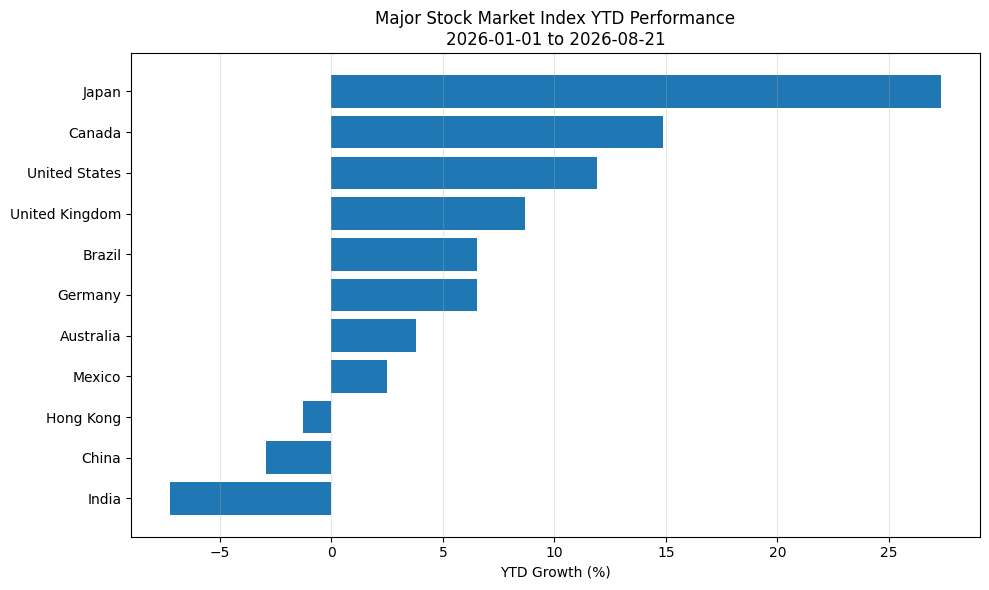

In [17]:
# Optional: save to CSV
# df.to_csv("ytd_index_performance_2026.csv", index=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(df["Country"], df["YTD Growth (%)"])
plt.xlabel("YTD Growth (%)")
plt.title("Major Stock Market Index YTD Performance\n2026-01-01 to 2026-08-21")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Third question

In [31]:
# 1. Download S&P 500 daily data from 1950 to present
sp500 = yf.download("^GSPC", start="1950-01-01", progress=False, auto_adjust=False)

# Handle possible MultiIndex columns from yfinance
if isinstance(sp500.columns, pd.MultiIndex):
    close = sp500["Close"]["^GSPC"]
else:
    close = sp500["Close"]

close = close.dropna().sort_index()

In [19]:
# 2. Identify all-time highs (strictly exceed all previous closing prices)
running_max = close.cummax()
ath_mask = close > running_max.shift(1)
ath_mask.iloc[0] = True  # treat the first observation as the initial ATH
ath = close[ath_mask]

In [20]:
# 3-6. For each pair of consecutive ATHs, find the minimum in between,
#       calculate drawdown, filter >= 5%, and record duration.
corrections = []
ath_dates = ath.index

for i in range(len(ath_dates) - 1):
    peak_date = ath_dates[i]
    next_peak_date = ath_dates[i + 1]
    peak_price = close.loc[peak_date]

    # Minimum closing price between this ATH and the next ATH
    segment = close.loc[peak_date:next_peak_date]
    trough_date = segment.idxmin()
    trough_price = segment.min()

    drawdown_pct = (peak_price - trough_price) / peak_price * 100
    duration_days = (trough_date - peak_date).days

    if drawdown_pct >= 5.0:
        corrections.append({
            "Peak Date": peak_date.date(),
            "Trough Date": trough_date.date(),
            "Peak Price": round(peak_price, 2),
            "Trough Price": round(trough_price, 2),
            "Drawdown (%)": round(drawdown_pct, 2),
            "Duration (days)": duration_days
        })

df = pd.DataFrame(corrections)

In [21]:
# 7. Percentiles and median drawdown
percentiles = df[["Drawdown (%)", "Duration (days)"]].quantile([0.25, 0.5, 0.75])
median_drawdown = df["Drawdown (%)"].median()
median_duration = df["Duration (days)"].median()

In [22]:
# Display results
print("Top 10 largest corrections by drawdown:")
print(df.sort_values("Drawdown (%)", ascending=False).head(10).to_string(index=False))

print("\nPercentiles (25th, 50th, 75th):")
print(percentiles)

print(f"\nMedian drawdown of corrections >= 5%: {median_drawdown:.2f}%")
print(f"Median duration of corrections >= 5%: {median_duration:.0f} days")

Top 10 largest corrections by drawdown:
 Peak Date Trough Date  Peak Price  Trough Price  Drawdown (%)  Duration (days)
2007-10-09  2009-03-09     1565.15        676.53         56.78              517
2000-03-24  2002-10-09     1527.46        776.76         49.15              929
1973-01-11  1974-10-03      120.24         62.28         48.20              630
1968-11-29  1970-05-26      108.37         69.29         36.06              543
2020-02-19  2020-03-23     3386.15       2237.40         33.92               33
1987-08-25  1987-12-04      336.77        223.92         33.51              101
1961-12-12  1962-06-26       72.64         52.32         27.97              196
1980-11-28  1982-08-12      140.52        102.42         27.11              622
2022-01-03  2022-10-12     4796.56       3577.03         25.43              282
1966-02-09  1966-10-07       94.06         73.20         22.18              240

Percentiles (25th, 50th, 75th):
      Drawdown (%)  Duration (days)
0.25       

## Fourth Question

In [33]:
ticker = 'AMZN'
t = yf.Ticker(ticker)

# ---------- 1. Load earnings dates ----------
earnings = t.get_earnings_dates()
print("Raw earnings rows:", len(earnings))

# Drop the future earnings date (no Reported EPS / Surprise % yet)
earnings = earnings.dropna(subset=['Reported EPS', 'Surprise(%)']).copy()
earnings.index = pd.to_datetime(earnings.index)
if earnings.index.tz is not None:
    earnings.index = earnings.index.tz_localize(None)
earnings.index = earnings.index.normalize()
print(yf.Ticker('AMZN').get_earnings_dates().columns.tolist())
print(f"Earnings dates with reported surprises: {len(earnings)}")
print(earnings[['Reported EPS', 'Surprise(%)']].head())

Raw earnings rows: 25
['EPS Estimate', 'Reported EPS', 'Surprise(%)']
Earnings dates with reported surprises: 24
               Reported EPS  Surprise(%)
Earnings Date                           
2026-07-30             5.75       215.02
2026-04-29             2.78        69.02
2026-02-05             1.95         0.22
2025-10-30             1.95        25.20
2025-07-31             1.68        27.19


In [34]:
# ---------- 2. Download full historical price data ----------
prices = t.history(period='max', auto_adjust=False)
close = prices['Close'].dropna()
close.index = pd.to_datetime(close.index)
if close.index.tz is not None:
    close.index = close.index.tz_localize(None)
close.index = close.index.normalize()

In [35]:
# ---------- 3. Compute 2-day returns for ALL trading days ----------
# For each triple (Day1, Day2, Day3): return = Close_Day3 / Close_Day1 - 1
two_day_returns = close.shift(-2) / close - 1
two_day_returns = two_day_returns.dropna()

In [37]:
# ---------- 4. Match each earnings date to its trading-day triple ----------
records = []
for e_date, row in earnings.iterrows():
    # First trading day on or after the earnings date → assume this is Day 2
    pos = close.index.searchsorted(e_date, side='left')
    if pos == 0 or pos >= len(close) - 1:
        continue  # need a Day 1 and a Day 3

    day1 = close.index[pos - 1]
    day2 = close.index[pos]
    day3 = close.index[pos + 1]

    ret_2d = close.loc[day3] / close.loc[day1] - 1

    records.append({
        'Earnings Date':  e_date.date(),
        'Day1':           day1.date(),
        'Day2 (earnings)': day2.date(),
        'Day3':           day3.date(),
        'Surprise (%)':   row['Surprise(%)'],
        '2-Day Return (%)': ret_2d * 100,
    })

df = pd.DataFrame(records)
print("\nEarnings-aligned 2-day returns:")
print(df.to_string(index=False))


Earnings-aligned 2-day returns:
Earnings Date       Day1 Day2 (earnings)       Day3  Surprise (%)  2-Day Return (%)
   2026-07-30 2026-07-29      2026-07-30 2026-07-31        215.02         19.823514
   2026-04-29 2026-04-28      2026-04-29 2026-04-30         69.02          2.063914
   2026-02-05 2026-02-04      2026-02-05 2026-02-06          0.22         -9.730030
   2025-10-30 2025-10-29      2025-10-30 2025-10-31         25.20          6.044289
   2025-07-31 2025-07-30      2025-07-31 2025-08-01         27.19         -6.707503
   2025-05-01 2025-04-30      2025-05-01 2025-05-02         16.77          3.014856
   2025-02-06 2025-02-05      2025-02-06 2025-02-07         25.29         -2.972437
   2024-10-31 2024-10-30      2024-10-31 2024-11-01         25.22          2.698074
   2024-08-01 2024-07-31      2024-08-01 2024-08-02         23.76        -10.204301
   2024-04-30 2024-04-29      2024-04-30 2024-05-01         17.67         -1.083116
   2024-02-01 2024-01-31      2024-02-01 20

In [38]:
# ---------- 5. Filter for positive surprises & compute median ----------
pos = df[df['Surprise (%)'] > 0].copy()
median_2day = pos['2-Day Return (%)'].median()

print(f"\nPositive surprise events: {len(pos)} of {len(df)}")
print(f"Median 2-day return after positive surprises: {median_2day:.2f}%")


Positive surprise events: 20 of 24
Median 2-day return after positive surprises: 0.35%


In [39]:
# ---------- 6. Correlation between surprise magnitude and 2-day return ----------
# Use pd.corr() on the two columns
corr_matrix = pos[['Surprise (%)', '2-Day Return (%)']].corr()
print("\nCorrelation matrix (positive surprises only):")
print(corr_matrix)

corr = pos['Surprise (%)'].corr(pos['2-Day Return (%)'])
print(f"\nCorrelation(surprise %, 2-day return %) = {corr:.4f}")


Correlation matrix (positive surprises only):
                  Surprise (%)  2-Day Return (%)
Surprise (%)          1.000000          0.330645
2-Day Return (%)      0.330645          1.000000

Correlation(surprise %, 2-day return %) = 0.3306
